Main script for Superlet-based time-frequency analysis of sEMG signals.
Developed for the manuscript:
'Enhanced Time-Frequency Analysis of Surface Electromyography using Superlet Transform' by Algaba-Vidoy et al., 2026 (under revision).

This script implements an adapted version of the Superlet Transform (SLT), originally proposed by Moca et al. 2021, tailored for surface electromyography (sEMG) signal analysis.

In addition to computing the SLT, this framework performs a systematic evaluation of its performance, benchmarking it against established time-frequency methods such as the Short-Time Fourier Transform (STFT) and the Continuous Wavelet Transform (CWT).

The implementation is conceived and optimized for sEMG applications, including spectral feature extraction, generation of sEMG simulated signals, noise addition and assessment, and time-frequency resolution analysis.

This code is part of the research work currently under review and is intended to support reproducibility and validation of the proposed methodology.

Implementation by Marina Algaba Vidoy

In [89]:
import sys
import matplotlib.pyplot as plt
import numpy as np
import importlib
import os
import cmcrameri.cm as cmc

from scipy.signal import stft
from scipy.signal import windows

import superlets_package.auxiliar_functions as aux
import superlets_package.cwt as cwt
import superlets_package.superlets_emg as superlet

sys.path.insert(0, '..')
print(sys.path)

['..', '..', '..', '/Applications/PyCharm.app/Contents/plugins/python/helpers-pro/jupyter_debug', '/Applications/PyCharm.app/Contents/plugins/python/helpers/pydev', '..', '/Users/neuralrehabilitationgroup/PycharmProjects/Superlets-Marina', '/Users/neuralrehabilitationgroup/PycharmProjects/SingularSuperletPY', '/opt/anaconda3/envs/Superlets-Marina/lib/python38.zip', '/opt/anaconda3/envs/Superlets-Marina/lib/python3.8', '/opt/anaconda3/envs/Superlets-Marina/lib/python3.8/lib-dynload', '', '/opt/anaconda3/envs/Superlets-Marina/lib/python3.8/site-packages', '/opt/anaconda3/envs/Superlets-Marina/lib/python3.8/site-packages/setuptools/_vendor']


In [90]:
importlib.reload(superlet)

<module 'superlets_package.superlets_emg' from '/Users/neuralrehabilitationgroup/PycharmProjects/Superlets-Marina/superlets_package/superlets_emg.py'>

In [91]:
importlib.reload(cwt)

<module 'superlets_package.cwt' from '/Users/neuralrehabilitationgroup/PycharmProjects/Superlets-Marina/superlets_package/cwt.py'>

In [92]:
importlib.reload(aux)

<module 'superlets_package.auxiliar_functions' from '/Users/neuralrehabilitationgroup/PycharmProjects/Superlets-Marina/superlets_package/auxiliar_functions.py'>

In [93]:
fontsize_title = 10
fontsize_subtitle = 16
fontsize_ticks = 12
fontsize_labels = 14
fontsize_legend = 14

# Create simulated signals

### Signal parameters

In [94]:
fs = 1024
signal_duration = 3
t = np.linspace(0, signal_duration, signal_duration * fs)

### Baseline noise

In [95]:
np.random.seed(10)
noise = np.random.normal(0, 0.01, len(t))

### Burst parameters

In [96]:
burst_duration = 0.5
burst_start = 1
real_t_onset = burst_start
real_t_offset = burst_start + burst_duration

start_idx = int(real_t_onset * fs)
end_idx = int(real_t_offset * fs)

### De Luca method to create burst with a known frequency

MNF ideal = 115.72429511777993
MNF analytic = 123.27802997905654


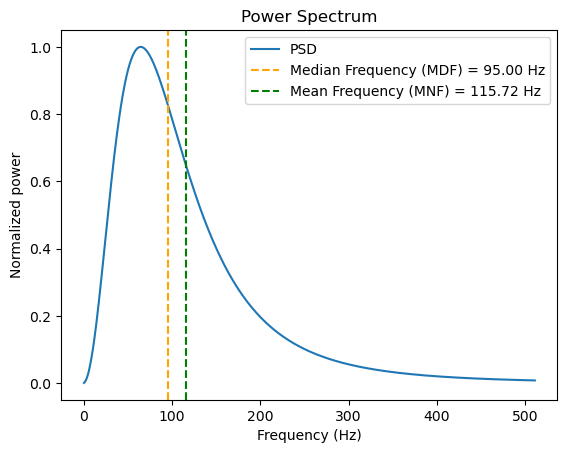

In [97]:
[_, PdeLuca, burst, MNF_ideal, MNF_analytic] = aux.fdeluca(120, 60, fs, burst_duration, plot=False)
print(f'MNF ideal = {MNF_ideal}')
print(f'MNF analytic = {MNF_analytic}')

### Create the signal

In [98]:
burst_signal = noise.copy()
burst_signal[int(burst_start * fs):int(burst_start * fs + len(burst))] += burst

### Signal visualization

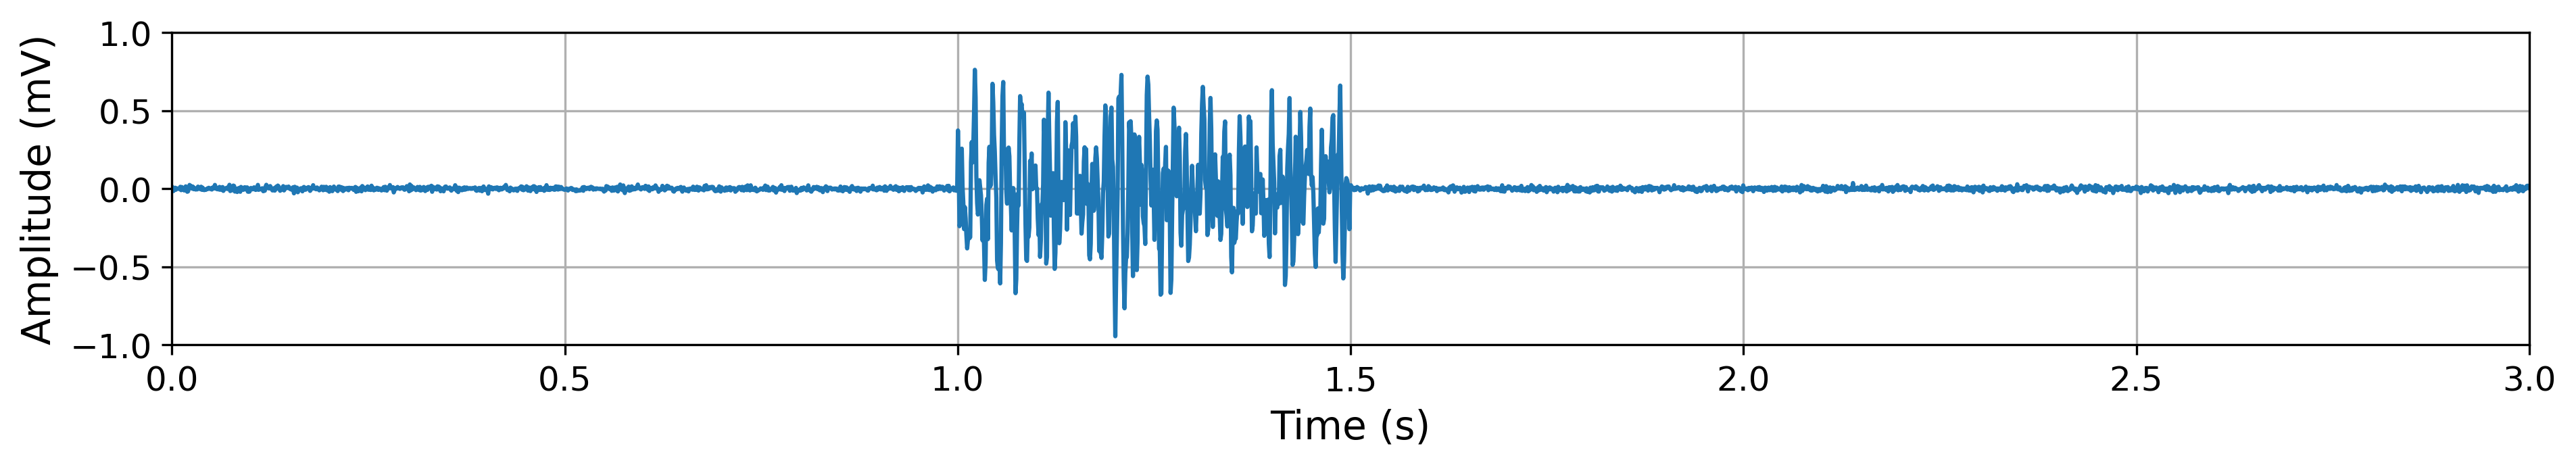

In [99]:
fig, ax = plt.subplots(figsize=(15, 2), dpi=300)
ax.set_xlabel("Time (s)", fontsize=fontsize_labels)
ax.set_ylabel("Amplitude (mV)", fontsize=fontsize_labels)
ax.set_xlim(0,3)
ax.set_ylim(-1,1)

ax.plot(np.linspace(0, len(burst_signal)/fs, len(burst_signal)), burst_signal)

ax.tick_params(axis='both', labelsize=fontsize_ticks)
ax.grid(True)   

# Definition of the frequency of interest

In [100]:
freqs = np.linspace(10,500,int(fs/2))

f_min = 10
f_max = 300

### Add noise to the signal with a particular value for SNR

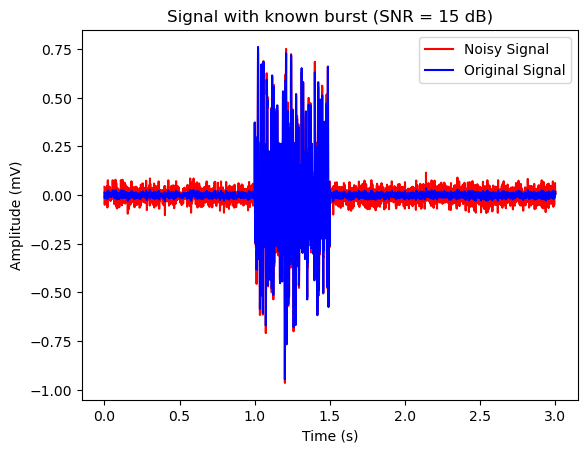

15.416417790336236 dB


In [101]:
SNR = 15
signal, xn = aux.add_noise(burst_signal, SNR, fs, plot = True)
real_snr = aux.compute_snr(signal, xn)
print(f'{real_snr} dB')

# Continuous Wavelet Transform

In [102]:
plot_tf_representation = True
plot_responses = True

In [104]:
params_wavelet = [100, 130, 230]

Processing parameter set number 1 --> c=100 cycles
Estimated mean frequency = 117.674 Hz
MAE_f = 6.410 ± 4.667 Hz
Estimated onset = 0.862 s
Estimated offset = 1.633 s
MAE_t = 0.183 ± 0.270 s
---------------------------------------------------------------------------
Processing parameter set number 2 --> c=130 cycles
Estimated mean frequency = 118.246 Hz
MAE_f = 6.515 ± 4.805 Hz
Estimated onset = 0.861 s
Estimated offset = 1.632 s
MAE_t = 0.182 ± 0.269 s
---------------------------------------------------------------------------
Processing parameter set number 3 --> c=230 cycles
Estimated mean frequency = 119.240 Hz
MAE_f = 6.907 ± 5.074 Hz
Estimated onset = 0.862 s
Estimated offset = 1.625 s
MAE_t = 0.176 ± 0.263 s
---------------------------------------------------------------------------


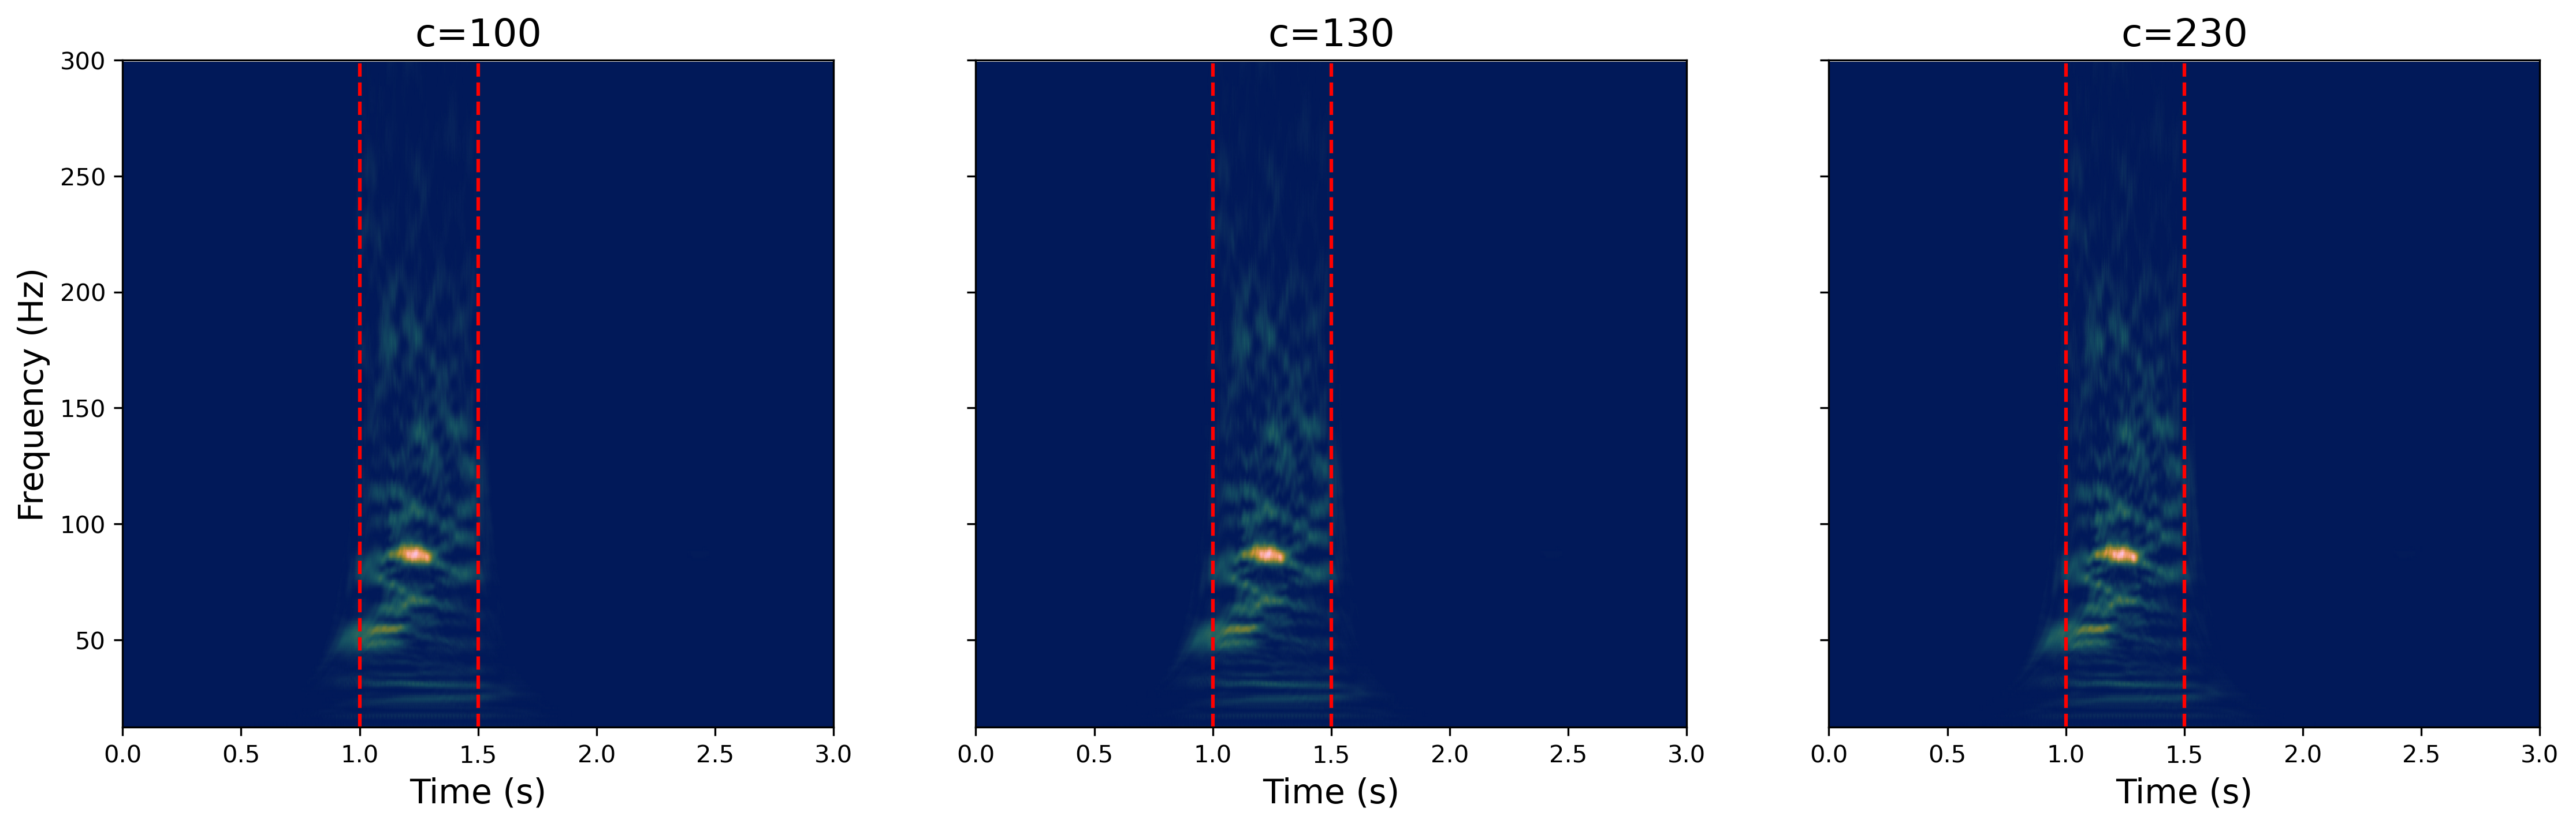

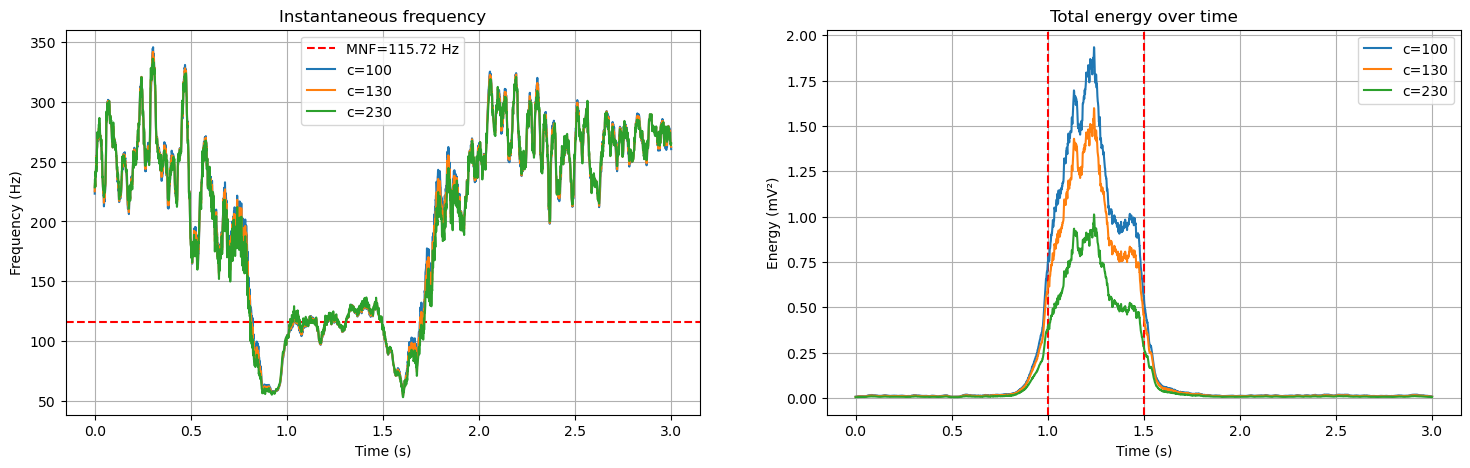

In [118]:
if plot_tf_representation:
    fig, ax = plt.subplots(ncols=len(params_wavelet), figsize=(18,5), dpi=300, sharey=True, sharex=True)
if plot_responses:
    fig_2, (ax_freq, ax_energy) = plt.subplots(1, 2, figsize=(18, 5))
    ax_freq.axhline(MNF_ideal, color='red', linestyle='--', label=f'MNF={MNF_ideal:.2f} Hz')
    ax_energy.axvline(real_t_onset, color='red', linestyle='--')
    ax_energy.axvline(real_t_offset, color='red', linestyle='--')

for i, c in enumerate(params_wavelet):
    print(f'Processing parameter set number {i+1} --> c={c} cycles')
    wavelet = f'cmor{c}-1.0'
    
    cwtmatr, f_cwt, physical_freqs = cwt.wavelet_transform(signal,wavelet,freqs,fs)
    scalogram_cwt = np.abs(cwtmatr)**2
    
    if plot_tf_representation:     
        # Define limits for the TF power representations
        mask_cwt = (f_cwt >= f_min) & (f_cwt <= f_max)
        
        pcm = ax[i].pcolormesh(t, f_cwt[mask_cwt], scalogram_cwt[mask_cwt,:], shading='gouraud', cmap=cmc.batlow)
        
        ax[i].axvline(real_t_onset, color='red', linestyle='--')
        ax[i].axvline(real_t_offset, color='red', linestyle='--')
        ax[i].set_title(f'c={c}', fontsize=fontsize_subtitle)
        ax[i].set_ylabel('Frequency (Hz)' if i == 0 else '', fontsize=fontsize_labels)
        ax[i].set_xlabel('Time (s)', fontsize=fontsize_labels)
        
        ax[i].set_ylim(f_cwt[0], f_max)

    # Energy in time is given directly by the scalogram (np.abs(X)**2)
    first_indices = []
    last_indices = []
    
    # We compute one t_onset and t_offset for each frequency bin in the scalogram (that's why we don´t do energy_t = np.sum(scalogram_cwt, axis=0))
    for row in scalogram_cwt:
        first_index, last_index = aux.find_plateau_region(row, burst_start, burst_duration, t, fs, plot_results=False)
        first_indices.append(first_index)
        last_indices.append(last_index)
        
    t_onset = t[first_indices]
    t_offset = t[last_indices]
    
    # Compute the instantaneous frequency
    instant_freq = np.sum(scalogram_cwt * f_cwt[:, np.newaxis], axis=0) / np.sum(scalogram_cwt, axis=0)
    instant_mean_freq_burst = instant_freq[start_idx:end_idx]
    
    if plot_responses:
        ax_freq.plot(t, instant_freq, label=f"c={c}")
        ax_freq.set_xlabel("Time (s)")
        ax_freq.set_ylabel("Frequency (Hz)")
        ax_freq.set_title("Instantaneous frequency")
        ax_freq.legend()
        ax_freq.grid(True)
        
        ax_energy.plot(t, np.sum(scalogram_cwt, axis=0), label=f"c={c}")
        ax_energy.set_xlabel("Time (s)")
        ax_energy.set_ylabel("Energy (mV²)")
        ax_energy.set_title("Total energy over time")
        ax_energy.legend()
        ax_energy.grid(True)
        
    # Compute MAE in frequency (MAE_f)
    print(f'Estimated mean frequency = {np.mean(instant_mean_freq_burst):.3f} Hz')
    mae_f, std_f = aux.calculate_mae(instant_mean_freq_burst, MNF_ideal)
    print(f"MAE_f = {mae_f:.3f} ± {std_f:.3f} Hz")
    
    # Compute MAE in time (MAE_t)
    print(f'Estimated onset = {np.mean(t_onset):.3f} s')
    print(f'Estimated offset = {np.mean(t_offset):.3f} s')
    mae_t, std_t = aux.calculate_mae((t_onset,t_offset), (real_t_onset,real_t_offset))
    print(f"MAE_t = {mae_t:.3f} ± {std_t:.3f} s")
    print('---------------------------------------------------------------------------')

# Superlet Transform

In [109]:
params_superlet = [[2,3,6],[3,4,7],[220,250,300]]

Processing parameter set number 1 --> c₁=2, o=3,220
Estimated mean frequency = 117.544 Hz
MAE_f = 5.894 ± 4.004 Hz
Estimated onset = 0.930 s
Estimated offset = 1.587 s
MAE_t = 0.153 ± 0.223 s
---------------------------------------------------------------------------
Processing parameter set number 2 --> c₁=3, o=4,250
Estimated mean frequency = 118.152 Hz
MAE_f = 4.507 ± 2.542 Hz
Estimated onset = 0.883 s
Estimated offset = 1.634 s
MAE_t = 0.176 ± 0.238 s
---------------------------------------------------------------------------
Processing parameter set number 3 --> c₁=6, o=7,300
Estimated mean frequency = 120.905 Hz
MAE_f = 5.181 ± 2.227 Hz
Estimated onset = 0.733 s
Estimated offset = 1.776 s
MAE_t = 0.285 ± 0.251 s
---------------------------------------------------------------------------


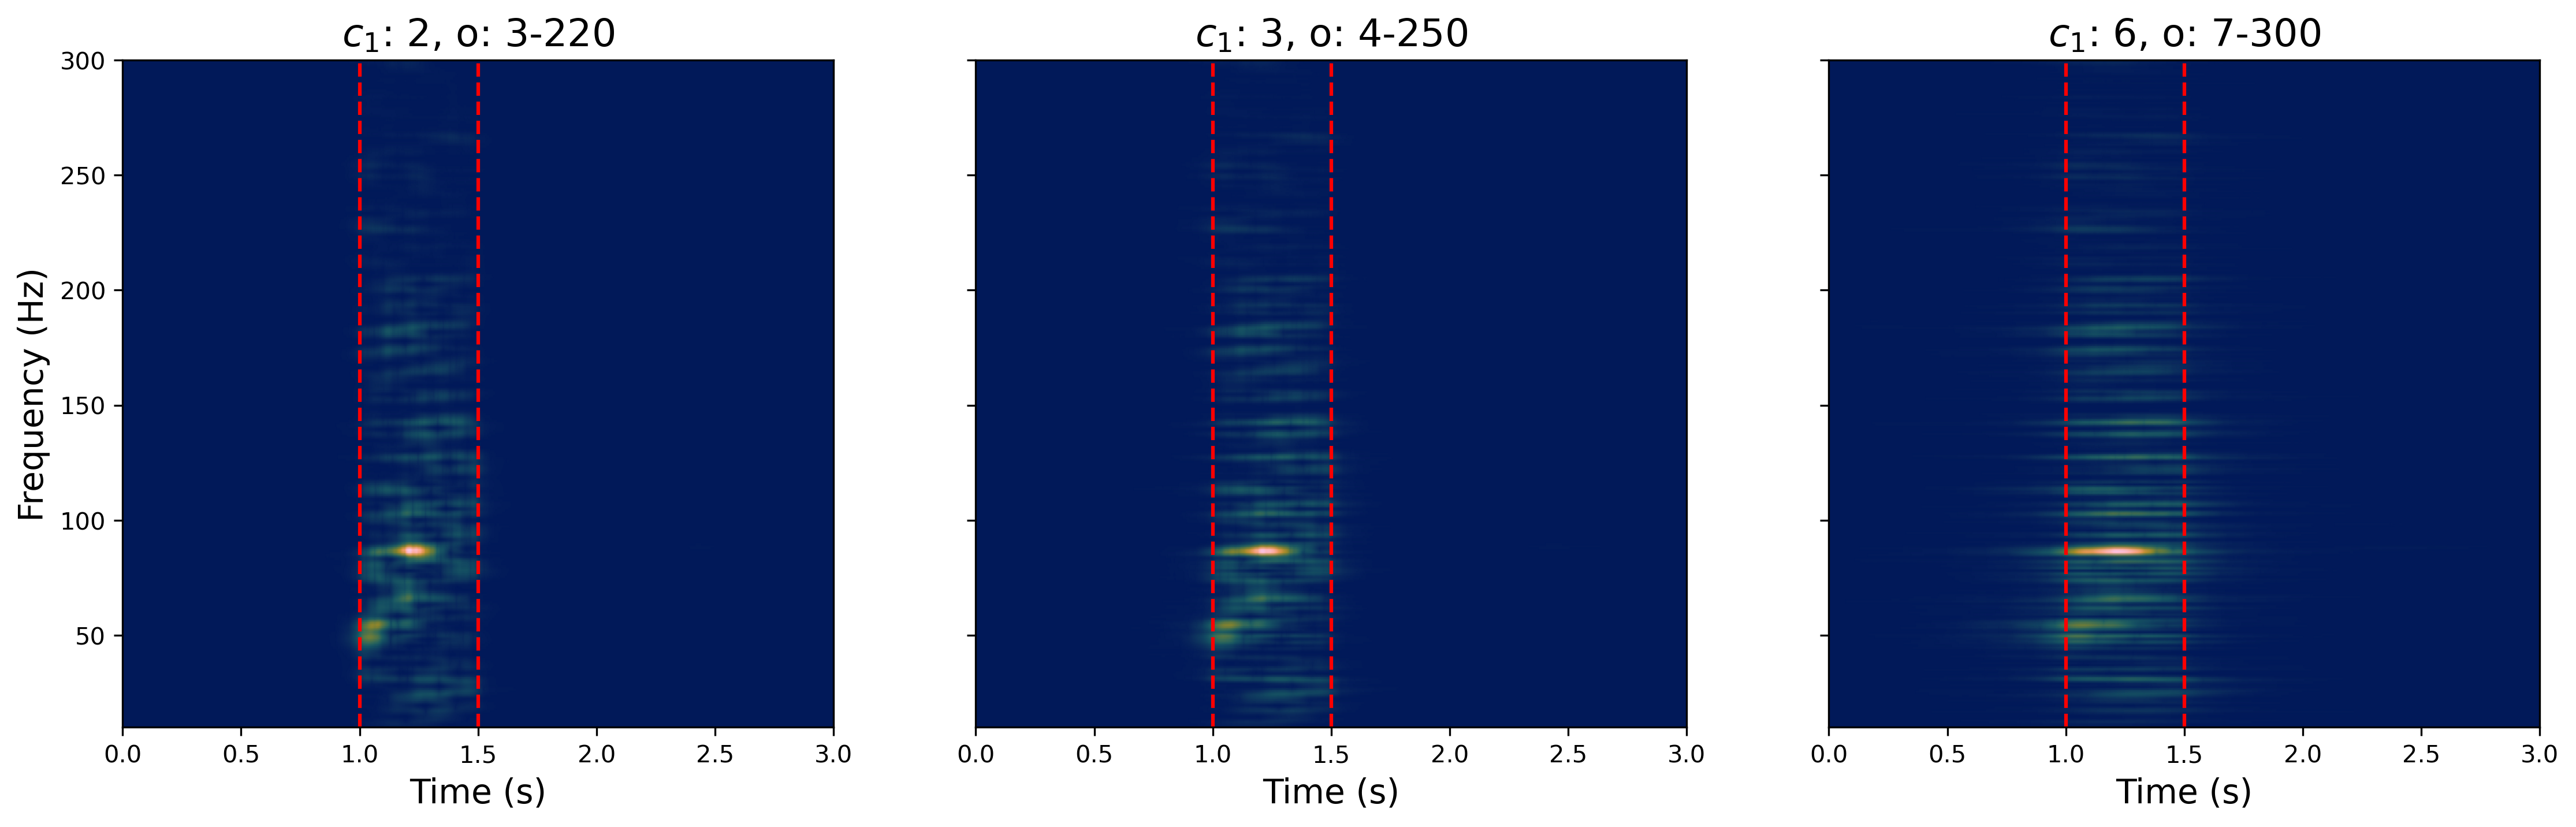

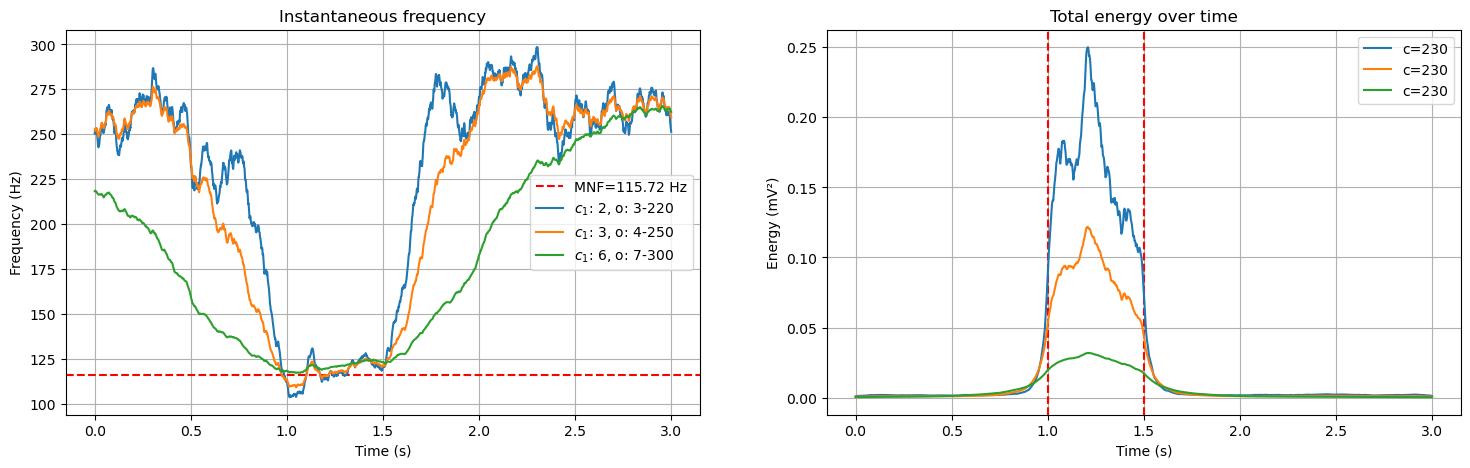

In [119]:
if plot_tf_representation:
    fig, ax = plt.subplots(ncols=len(params_superlet), figsize=(18,5), dpi=300, sharey=True, sharex=True)
if plot_responses:
    fig_2, (ax_freq, ax_energy) = plt.subplots(1, 2, figsize=(18, 5))
    ax_freq.axhline(MNF_ideal, color='red', linestyle='--', label=f'MNF={MNF_ideal:.2f} Hz')
    ax_energy.axvline(real_t_onset, color='red', linestyle='--')
    ax_energy.axvline(real_t_offset, color='red', linestyle='--')

for (i, (base_cycle, min_order, max_order)) in enumerate(zip(*params_superlet)):
    print(f"Processing parameter set number {i+1} --> c₁={base_cycle}, o={min_order},{max_order}")

    # Returns the scalogram (squared magnitude of the SLT coefficients)
    _, scalogram_slt = superlet.adaptive_superlet_transform(signal, freqs, sampling_freq=fs,
                                                         base_cycle=base_cycle, min_order=min_order,
                                                         max_order=max_order, mode="mul")
    
    if plot_tf_representation:
        mask_slt = (freqs >= f_min) & (freqs <= f_max)
        im = ax[i].pcolormesh(t, freqs[mask_slt], scalogram_slt[mask_slt,:], shading='gouraud', cmap=cmc.batlow)
        
        # For a faster representation
        # im = ax[i].imshow(scalogram_slt[mask_slt,:], aspect='auto', cmap=cmc.batlow, interpolation="none", origin="lower",extent=[0, len(signal_5)/fs, freqs[mask_slt][0], freqs[mask_slt][-1]])
        
        ax[i].axvline(real_t_onset, color='red', linestyle='--')
        ax[i].axvline(real_t_offset, color='red', linestyle='--')
        ax[i].set_title(f"$c_1$: {base_cycle}, o: {min_order}-{max_order}", fontsize=fontsize_subtitle)
        ax[i].set_xlabel("Time (s)", fontsize=fontsize_labels)
        ax[i].set_ylabel('Frequency (Hz)' if i == 0 else '', fontsize=fontsize_labels)
        ax[i].set_ylim(f_min, f_max)
        ax[i].grid(False)
   
    # Energy in time is given directly by the scalogram
    first_indices = []
    last_indices = []
    
    # We compute one t_onset and t_offset for each frequency bin in the scalogram (that's why we don´t do energy_t = np.sum(scalogram_cwt, axis=0))

    for row in scalogram_slt:
        first_index, last_index = aux.find_plateau_region(row, burst_start, burst_duration, t, fs, plot_results=False)
        first_indices.append(first_index)
        last_indices.append(last_index)
        
    t_onset = t[first_indices]
    t_offset = t[last_indices]
    
    # Compute the instantaneous frequency
    instant_freq = np.sum(scalogram_slt * freqs[:, np.newaxis], axis=0) / np.sum(scalogram_slt, axis=0)
    
    instant_mean_freq_burst = instant_freq[start_idx:end_idx]
    
    if plot_responses:
        ax_freq.plot(t, instant_freq, label=f"$c_1$: {base_cycle}, o: {min_order}-{max_order}")
        ax_freq.set_xlabel("Time (s)")
        ax_freq.set_ylabel("Frequency (Hz)")
        ax_freq.set_title("Instantaneous frequency")
        ax_freq.legend()
        ax_freq.grid(True)
        
        ax_energy.plot(t,  np.sum(scalogram_slt, axis=0), label=f"c={c}")
        ax_energy.set_xlabel("Time (s)")
        ax_energy.set_ylabel("Energy (mV²)")
        ax_energy.set_title("Total energy over time")
        ax_energy.legend()
        ax_energy.grid(True)
        
    # Compute MAE in frequency
    print(f'Estimated mean frequency = {np.mean(instant_mean_freq_burst):.3f} Hz')
    mae_f, std_f = aux.calculate_mae(instant_mean_freq_burst, MNF_ideal)
    print(f"MAE_f = {mae_f:.3f} ± {std_f:.3f} Hz")
    
    # Compute MAE in time
    print(f'Estimated onset = {np.mean(t_onset):.3f} s')
    print(f'Estimated offset = {np.mean(t_offset):.3f} s')
    mae_t, std_t = aux.calculate_mae((t_onset,t_offset), (real_t_onset,real_t_offset))
    print(f"MAE_t = {mae_t:.3f} ± {std_t:.3f} s")
    print('---------------------------------------------------------------------------')

# Short-Time Fourier Transform

In [120]:
windows_ms = [24, 634, 986]

Processing parameter set number 1 --> w=24 ms
Estimated mean frequency = 128.273 Hz
MAE_f = 29.998 ± 25.595 Hz
Estimated onset = 0.916 s
Estimated offset = 1.585 s
MAE_t = 0.090 ± 0.225 s
---------------------------------------------------------------------------
Processing parameter set number 2 --> w=634 ms
Estimated mean frequency = 117.272 Hz
MAE_f = 3.863 ± 2.856 Hz
Estimated onset = 0.879 s
Estimated offset = 1.630 s
MAE_t = 0.197 ± 0.242 s
---------------------------------------------------------------------------
Processing parameter set number 3 --> w=986 ms
Estimated mean frequency = 117.257 Hz
MAE_f = 3.083 ± 1.980 Hz
Estimated onset = 0.819 s
Estimated offset = 1.687 s
MAE_t = 0.230 ± 0.246 s
---------------------------------------------------------------------------


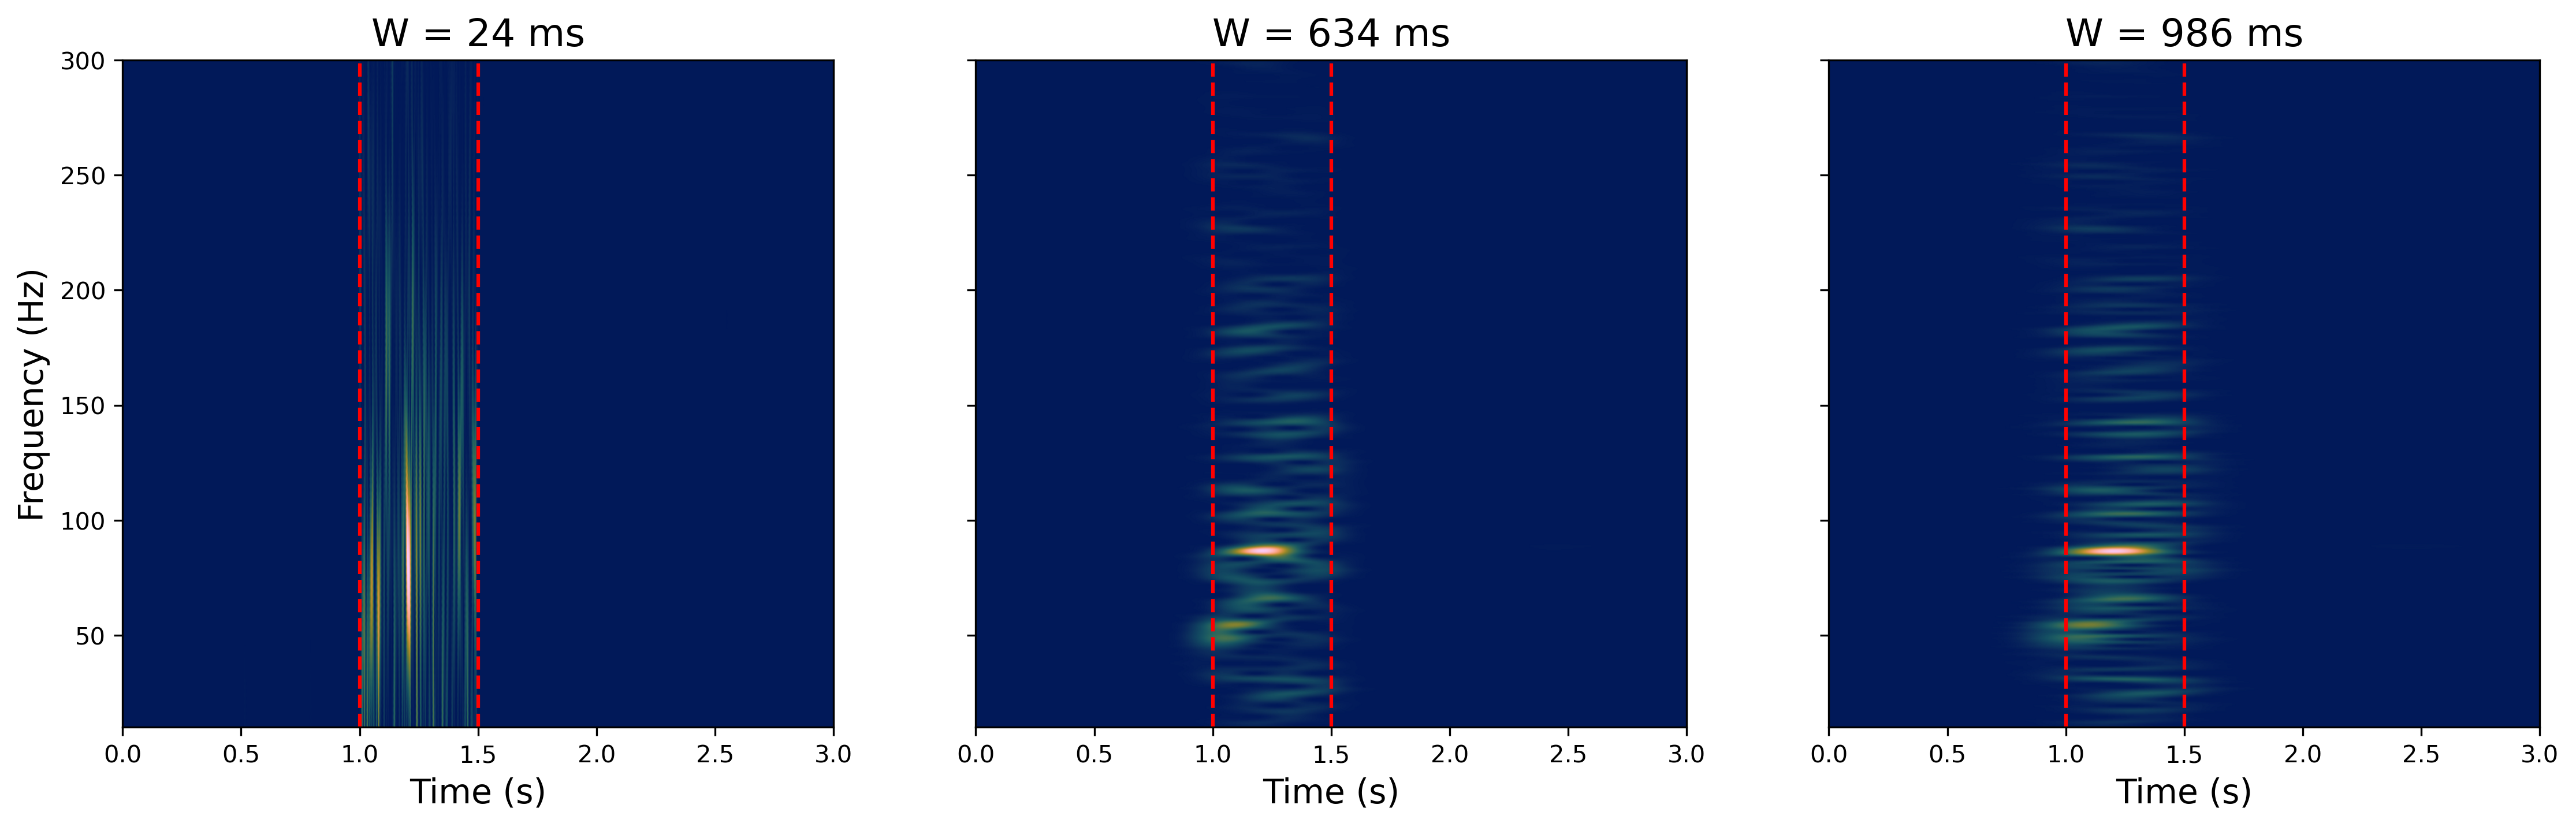

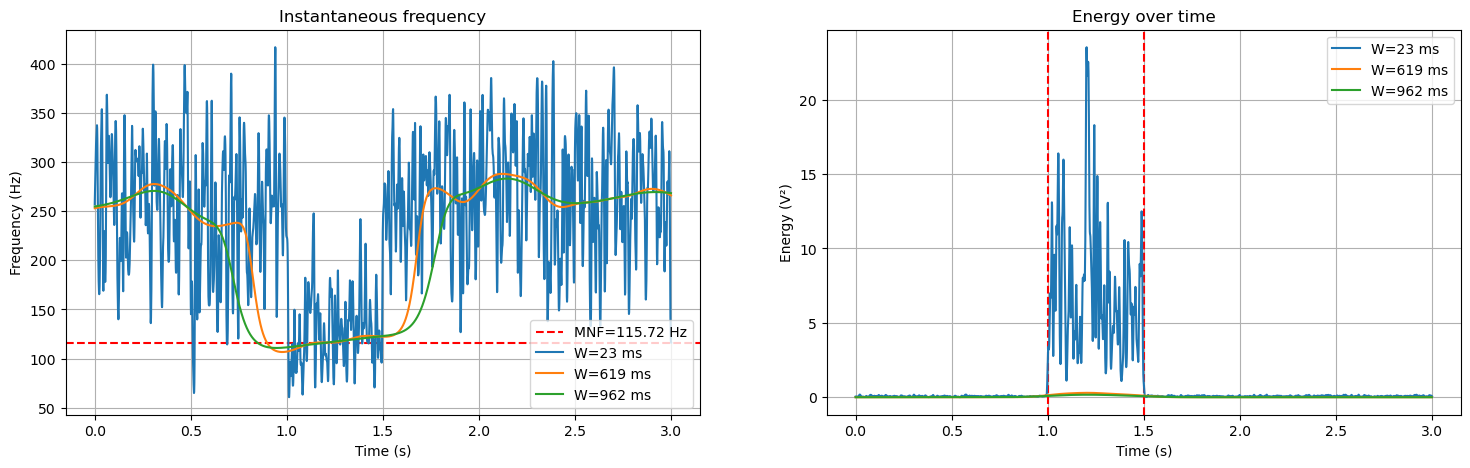

In [122]:
if plot_tf_representation:
    fig, ax = plt.subplots(ncols=len(windows_ms), figsize=(18,5), dpi=300, sharey=True, sharex=True)
if plot_responses:
    fig_2, (ax_freq, ax_energy) = plt.subplots(1, 2, figsize=(18, 5))  
    ax_freq.axhline(MNF_ideal, color='red', linestyle='--', label=f'MNF={MNF_ideal:.2f} Hz')
    ax_energy.axvline(real_t_onset, color='red', linestyle='--')
    ax_energy.axvline(real_t_offset, color='red', linestyle='--')

for i, w in enumerate(windows_ms):
    print(f"Processing parameter set number {i+1} --> w={w} ms")
    w_frames = int((w / 1000) * fs)
    window = windows.blackman(w_frames)

    nfft = 4 * (len(freqs))

    f_stft, t_stft, Zxx = stft(signal, fs=fs, window=window, nperseg=w_frames, noverlap=w_frames-1, nfft=nfft, detrend=False, return_onesided=True, boundary='zeros', padded=True, axis=-1, scaling='spectrum')

    spectrogram = np.abs(Zxx) ** 2
    
    if plot_tf_representation:
        mask_stft = f_stft <= f_max
        
        im = ax[i].pcolormesh(t_stft, f_stft[mask_stft], spectrogram[mask_stft, :], shading="gouraud", cmap=cmc.batlow)
    
        ax[i].axvline(real_t_onset, color='red', linestyle='--')
        ax[i].axvline(real_t_offset, color='red', linestyle='--')
        ax[i].set_title(f'W = {w} ms', fontsize=fontsize_subtitle)
        ax[i].set_xlabel("Time (s)", fontsize=fontsize_labels)
    
        ax[i].set_ylabel('Frequency (Hz)' if i == 0 else '', fontsize=fontsize_labels)
    
        ax[i].set_ylim(f_min, f_max)
        ax[i].grid(False)

    instant_freq = np.sum(spectrogram * f_stft[:, np.newaxis], axis=0) / np.sum(spectrogram, axis=0)    
    energy = spectrogram
    
    first_indices = []
    last_indices = []
    
    for row in energy:
        first_index, last_index = aux.find_plateau_region(row, burst_start, burst_duration, t_stft, fs, plot_results=False)
        first_indices.append(first_index)
        last_indices.append(last_index)
    
    t_onset = t_stft[first_indices]
    t_offset = t_stft[last_indices]

    instant_mean_freq_burst = instant_freq[start_idx:end_idx]

    if plot_responses:
        ax_freq.plot(t_stft, instant_freq, label=f'W={w * 1000 // fs} ms')
        ax_freq.set_xlabel("Time (s)")
        ax_freq.set_ylabel("Frequency (Hz)")
        ax_freq.legend()
        ax_freq.grid(True)
        ax_freq.set_title("Instantaneous frequency")
        
        ax_energy.plot(t_stft,  np.sum(spectrogram, axis=0), label=f'W={w * 1000 // fs} ms')
        ax_energy.set_xlabel("Time (s)")
        ax_energy.set_ylabel("Energy (V²)")
        ax_energy.legend()
        ax_energy.grid(True)
        ax_energy.set_title("Energy over time")
        
    # Compute MAE in frequency
    print(f'Estimated mean frequency = {np.mean(instant_mean_freq_burst):.3f} Hz')
    mae_f, std_f = aux.calculate_mae(instant_mean_freq_burst, MNF_ideal)
    print(f"MAE_f = {mae_f:.3f} ± {std_f:.3f} Hz")
    
    # Compute MAE in time
    print(f'Estimated onset = {np.mean(t_onset):.3f} s')
    print(f'Estimated offset = {np.mean(t_offset):.3f} s')
    mae_t, std_t = aux.calculate_mae((t_onset,t_offset), (real_t_onset,real_t_offset))
    print(f"MAE_t = {mae_t:.3f} ± {std_t:.3f} s")
    print('---------------------------------------------------------------------------')

References:

Moca, V. V., Bârzan, H., Nagy-Dăbâcan, A., & Mureșan, R. C. (2021). Time-frequency super-resolution with superlets. Nature Communications, 12(1), 337. https://doi.org/10.1038/s41467-020-20539-9